In [17]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)


# Imports
from stn_gpe import *
import numpy as np
from matplotlib import pyplot as plt
import scipy
from numpy.fft import fft, ifft
import math
from scipy.signal import spectrogram
from matplotlib.lines import Line2D
from tqdm.autonotebook import tqdm
from matplotlib.colors import LinearSegmentedColormap
# rc styling (Times New Roman + nicer defaults)
# ...existing code...
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "font.weight": "bold",         # global bold
    "axes.titlesize": 12,
    "axes.titleweight": "bold",    # bold axis titles
    "axes.labelsize": 11,
    "axes.labelweight": "bold",    # bold axis labels
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.grid": False
})
import pickle
import torch
# ...existing code...

Project root added to sys.path: d:\charitha\projects\STN-GPe_spiking\light_house_DBS_decision_making


In [20]:
# reading pkl file path

folder_path = os.path.join(project_root, 'results', 'stn_gpe_system', 'data', 'sector_DBS', 'raw_data', 'SECTOR_DBS_PI_20_ROT_2_HIGHAMP')
file_path = os.path.join(folder_path, 'spikes.pkl')

In [21]:
with open(file_path, 'rb') as f:
        SPIKES_DATA = pickle.load(f)

lat_strength_arr = list(SPIKES_DATA.keys())

In [25]:
for i in tqdm(range(1)):

        stn_lat = lat_strength_arr[i]
        Analysis_PD= Analysis(SPIKES_DATA[stn_lat])

        # ******************* mean rate *********************************
        rate_data_PD = Analysis_PD.spike_rate(binsize = 100)
        STN_4_PD = torch.tensor(np.array([rate_data_PD['1'], rate_data_PD['2'], rate_data_PD['3'], rate_data_PD['4']]))
        STN_4_PD_processed = torch.mean(STN_4_PD.reshape(4,-1,100), dim = 2)
        print(STN_4_PD_processed.T.shape)
        STN_4_PD_std = torch.std(STN_4_PD, dim = 0)
        STN_4_PD_std_processed = torch.std(STN_4_PD_processed, dim = 0)


        print(f'lat: {stn_lat}; STD: {STN_4_PD_std.mean()}; Processed STD: {STN_4_PD_std_processed.mean()}')


  0%|          | 0/1 [00:00<?, ?it/s]

torch.Size([200, 4])
lat: 0.0275; STD: 0.4895120794004492; Processed STD: 0.464496446183998


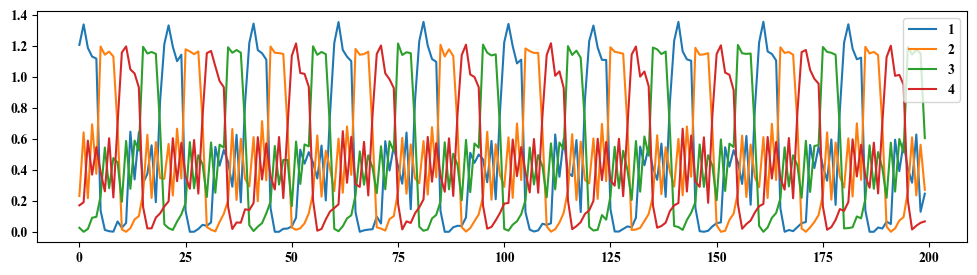

In [23]:
plt.figure(figsize=(12,3))
plt.plot(STN_4_PD_processed[0], label = '1')
plt.plot(STN_4_PD_processed[1], label = '2')
plt.plot(STN_4_PD_processed[2], label = '3')
plt.plot(STN_4_PD_processed[3], label = '4')
plt.legend()
plt.show()